In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import numpy as np
from torchvision import models
from collections import Counter, defaultdict
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Производим ресайз всех наших изображений в формат на которых обучалась вся ResNet
transforms_train = transforms.Compose([transforms.Resize((256, 256)), transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])])

transforms_test = transforms.Compose([transforms.Resize((256, 256)), transforms.CenterCrop(224), transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])])

# Чтение и просмотр количества классов(персонажей) в датасете
dataset_path = "simpsons_dataset"
base_dataset = ImageFolder(dataset_path)
print("Число классов:", len(base_dataset.classes))

rng = np.random.default_rng(42)

# Создаем словарик в котором будет значения(индексы картинки) и ключи(номера классов) для того, 
# чтобы N% изоражений ушло в train, а N% в test, без того что в test`e неожиданно попадется незнакомое для сетки фото
class_to_indices = defaultdict(list)
for idx, target in enumerate(base_dataset.targets):
    class_to_indices[target].append(idx)

# Хранение перемешанных картинок
train_indices = []
test_indices = []

# Пробегаемся по всем изображениям датасета, откуда 20% пойдет в тестовую выборку 
for cls, indices in class_to_indices.items():
    indices = np.array(indices)
    rng.shuffle(indices)
    n = len(indices)
    n_test = max(1, int(0.2 * n))

    # Тут происходит непосредственно, распределение на train и test
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    train_indices.extend(train_idx.tolist())
    test_indices.extend(test_idx.tolist())

print("Train size:", len(train_indices))
print("Test size:", len(test_indices))

# Cоздаем два независимых датасета с масками, на train применяется аугментация, на test применяется только центрирование
train_full = ImageFolder(dataset_path, transform=transforms_train)
test_full = ImageFolder(dataset_path, transform=transforms_test)

# Накладываем маcки
train_dataset = Subset(train_full, train_indices)
test_dataset = Subset(test_full, test_indices)

# Смотрим распределение классов в train и test
train_class_count = Counter(train_full.targets[i] for i in train_indices)
test_class_count = Counter(test_full.targets[i] for i in test_indices)

print("Train class count:", train_class_count)
print("Test class count:", test_class_count)

# Изображения будут грузиться в сетку по 32 картинки с перемешиванием, что даст гарантию получения сетки новых и новых вариаций батчей
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)


Counter({15: 1787, 28: 1172, 27: 1112, 4: 1082, 20: 1073, 22: 1041, 6: 982, 32: 958, 17: 954, 25: 864, 7: 800, 0: 726, 37: 703, 2: 507, 16: 388, 11: 376, 9: 366, 29: 296, 18: 243, 24: 205, 41: 143, 21: 107, 14: 91, 3: 87, 5: 85, 36: 82, 35: 67, 31: 60, 23: 56, 33: 52, 39: 42, 8: 38, 1: 35, 34: 33, 38: 32, 30: 28, 12: 22, 13: 21, 26: 16, 10: 7, 40: 6, 19: 2})


In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(in_features= 512, out_features= 41)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size= 30, gamma= 0.1)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(in_features= 512, out_features= 42)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size= 30, gamma= 0.1)

False
no gpu
cpu


In [ ]:
num_epoch = 7
best_accuracy = 0
checkpoint_every = 3

train_losses, train_accuracies, test_accuracies, epochs = [], [], [], []

# Режим тренировки с аугментацией, backprop
# В inputs будут подаваться тензоры в сетку [32, 3, 224, 224] и labels с правильными ответами для каждого класса
for epoch in range(num_epoch):
    model.train()
    train_loss, train_correct = 0, 0
    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1} / {num_epoch}'):
        inputs, labels = inputs.to(device), labels.to(device)

        # Стираем память о старых градиентах во избежание ошибки
        optimizer.zero_grad()
        outputs = model(inputs)

        # Даем сетке правильные ответы, которые она будет сравнивать со своими предсказаниями и в случае ошибки обновлять веса, до попадания в локальный минимум
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        
        train_loss += loss.item() # хранение ошибок для отрисовки графика
        _, predicted = outputs.max(1) # 
        train_correct += predicted.eq(labels).sum().item() # суммируем все правильные ответы для подсчета конечного accuracy
    train_accuracy = 100. * train_correct/len(train_dataset)
    
    
    # Перевод сетки в режим экзамена и отключение подсчета градиентов т.к это просто уже не надо
    # и дальше теже самые действия, что и на train
    model.eval()
    test_correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device, non_blocking = True), labels.to(device, non_blocking = True)
            
            # тоже самое что и на train
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_correct += predicted.eq(labels).sum().item()
    test_accuracy = 100. * test_correct / len(test_dataset)
    scheduler.step()
    
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    epochs.append(epoch + 1)
    print(f'Epoch {epoch + 1}: Train Acc {train_accuracy:.2f}% | Test Acc {test_accuracy:.2f}%')

    # Сохранение весов и дальнейшей статистики в файл на случай, если сетка сойдет с ума или произойдут перебои с железом
    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        torch.save(model.state_dict(), 'best_simpsons_resnet18.pth')
        print(f'New best: {best_accuracy:.2f}%')

    if (epoch + 1) % checkpoint_every == 0:
        checkpoint = {
            'epoch' : epoch,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict(),
            'scheduler_state_dict' : scheduler.state_dict(),
            'train_acc' : train_accuracy,
            'test_acc' : test_accuracy,
            'best_acc' : best_accuracy}
        torch.save(checkpoint, f'checkpoint_epoch_{epoch+1}.pth')

Epoch 1/7:   0%|          | 0/524 [00:00<?, ?it/s]c:\Users\AMADEY\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 1/7: 100%|██████████| 524/524 [13:32<00:00,  1.55s/it]


Epoch 1: Train Acc 74.80% | Test Acc 89.63%
New best: 89.63%


Epoch 2/7: 100%|██████████| 524/524 [13:27<00:00,  1.54s/it]


Epoch 2: Train Acc 96.86% | Test Acc 92.83%
New best: 92.83%


Epoch 3/7: 100%|██████████| 524/524 [16:39<00:00,  1.91s/it]  


...

Epoch 5: Train Acc 99.38% | Test Acc 95.82%
New best: 95.82%


Epoch 6/7: 100%|██████████| 524/524 [13:16<00:00,  1.52s/it]


Epoch 6: Train Acc 99.49% | Test Acc 95.84%
New best: 95.84%


Epoch 7/7: 100%|██████████| 524/524 [16:12<00:00,  1.86s/it]  


Epoch 7: Train Acc 99.59% | Test Acc 96.03%
New best: 96.03%


In [ ]:
from collections import defaultdict

model.eval()
correct_pred = defaultdict(int)
total_pred = defaultdict(int)

# Закинули батчи в сеть, достали макс. индексы каждого класса
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        c = (predicted == labels).squeeze() # Сравнение предсказания сетки и реальности
        
        # Конструкция превращает цифру 2 обратно в имя папки, например, "homer_simpson"
        for i in range(len(labels)):
            total_pred[test_dataset.dataset.classes[labels[i]]] += 1 
            if c[i]: # Если c[i] равно True (сеть угадала), мы добавляем +1 к Гомеру в словарик correct_pred
                correct_pred[test_dataset.dataset.classes[labels[i]]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * correct_count / total_pred[classname]
    print(f'{classname:12s}: {accuracy:.1f}%')

lisa_simpson: 96.1%
edna_krabappel: 93.8%
comic_book_guy: 98.1%
milhouse_van_houten: 96.7%
homer_simpson: 95.4%
apu_nahasapeemapetilon: 97.4%
moe_szyslak : 95.9%
waylon_smithers: 94.7%
ned_flanders: 97.9%
rainier_wolfcastle: 100.0%
abraham_grampa_simpson: 96.8%
principal_skinner: 96.2%
sideshow_mel: 75.0%
marge_simpson: 95.2%
nelson_muntz: 91.9%
charles_montgomery_burns: 96.2%
kent_brockman: 97.3%
krusty_the_clown: 97.6%
lenny_leonard: 95.5%
sideshow_bob: 98.3%
chief_wiggum: 96.8%
bart_simpson: 97.3%
martin_prince: 86.7%
barney_gumble: 78.9%
agnes_skinner: 85.7%
groundskeeper_willie: 100.0%
selma_bouvier: 90.5%
carl_carlson: 100.0%
patty_bouvier: 91.7%
maggie_simpson: 85.7%
mayor_quimby: 95.1%
otto_mann   : 100.0%
ralph_wiggum: 90.9%
snake_jailbird: 92.3%
professor_john_frink: 92.3%
cletus_spuckler: 77.8%
fat_tony    : 100.0%
gil         : 83.3%
troy_mcclure: 50.0%
miss_hoover : 100.0%


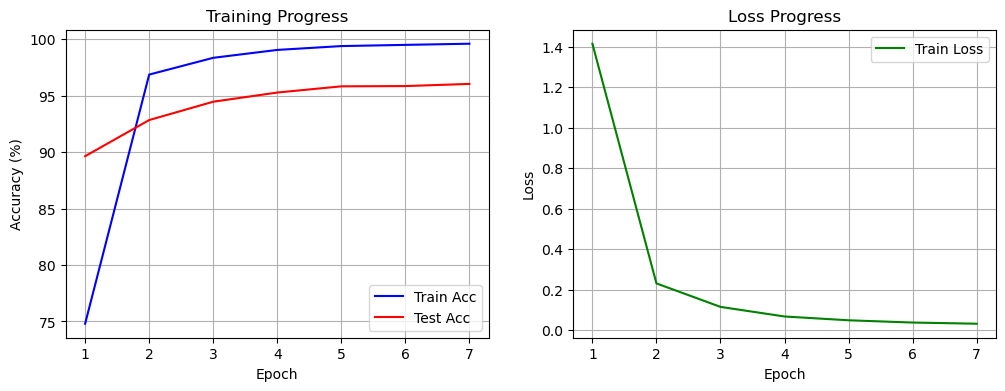

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))     
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, 'b-', label='Train Acc')
plt.plot(epochs, test_accuracies, 'r-', label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training Progress')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, 'g-', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Progress')
plt.grid(True)


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
        33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5]),
 [Text(0, 0.5, 'abraham_grampa_simpson'),
  Text(0, 1.5, 'agnes_skinner'),
  Text(0, 2.5, 'apu_nahasapeemapetilon'),
  Text(0, 3.5, 'barney_gumble'),
  Text(0, 4.5, 'bart_simpson'),
  Text(0, 5.5, 'carl_carlson'),
  Text(0, 6.5, 'charles_montgomery_burns'),
  Text(0, 7.5, 'chief_wiggum'),
  Text(0, 8.5, 'cletus_spuckler'),
  Text(0, 9.5, 'comic_book_guy'),
  Text(0, 10.5, 'disco_stu'),
  Text(0, 11.5, 'edna_krabappel'),
  Text(0, 12.5, 'fat_tony'),
  Text(0, 13.5, 'gil'),
  Text(0, 14.5, 'groundskeeper_willie'),
  Text(0, 15.5, 'homer_simpson'),
  Text(0, 16.5, 'kent_brockman'),
  Text(0, 17.5, 'krusty_the_clown'),
  Text(0, 18.5, 'lenny_leonard'),
  Text(0, 19.5, 'lionel_hutz'),
  Text(0, 20.5, 'lisa_sim

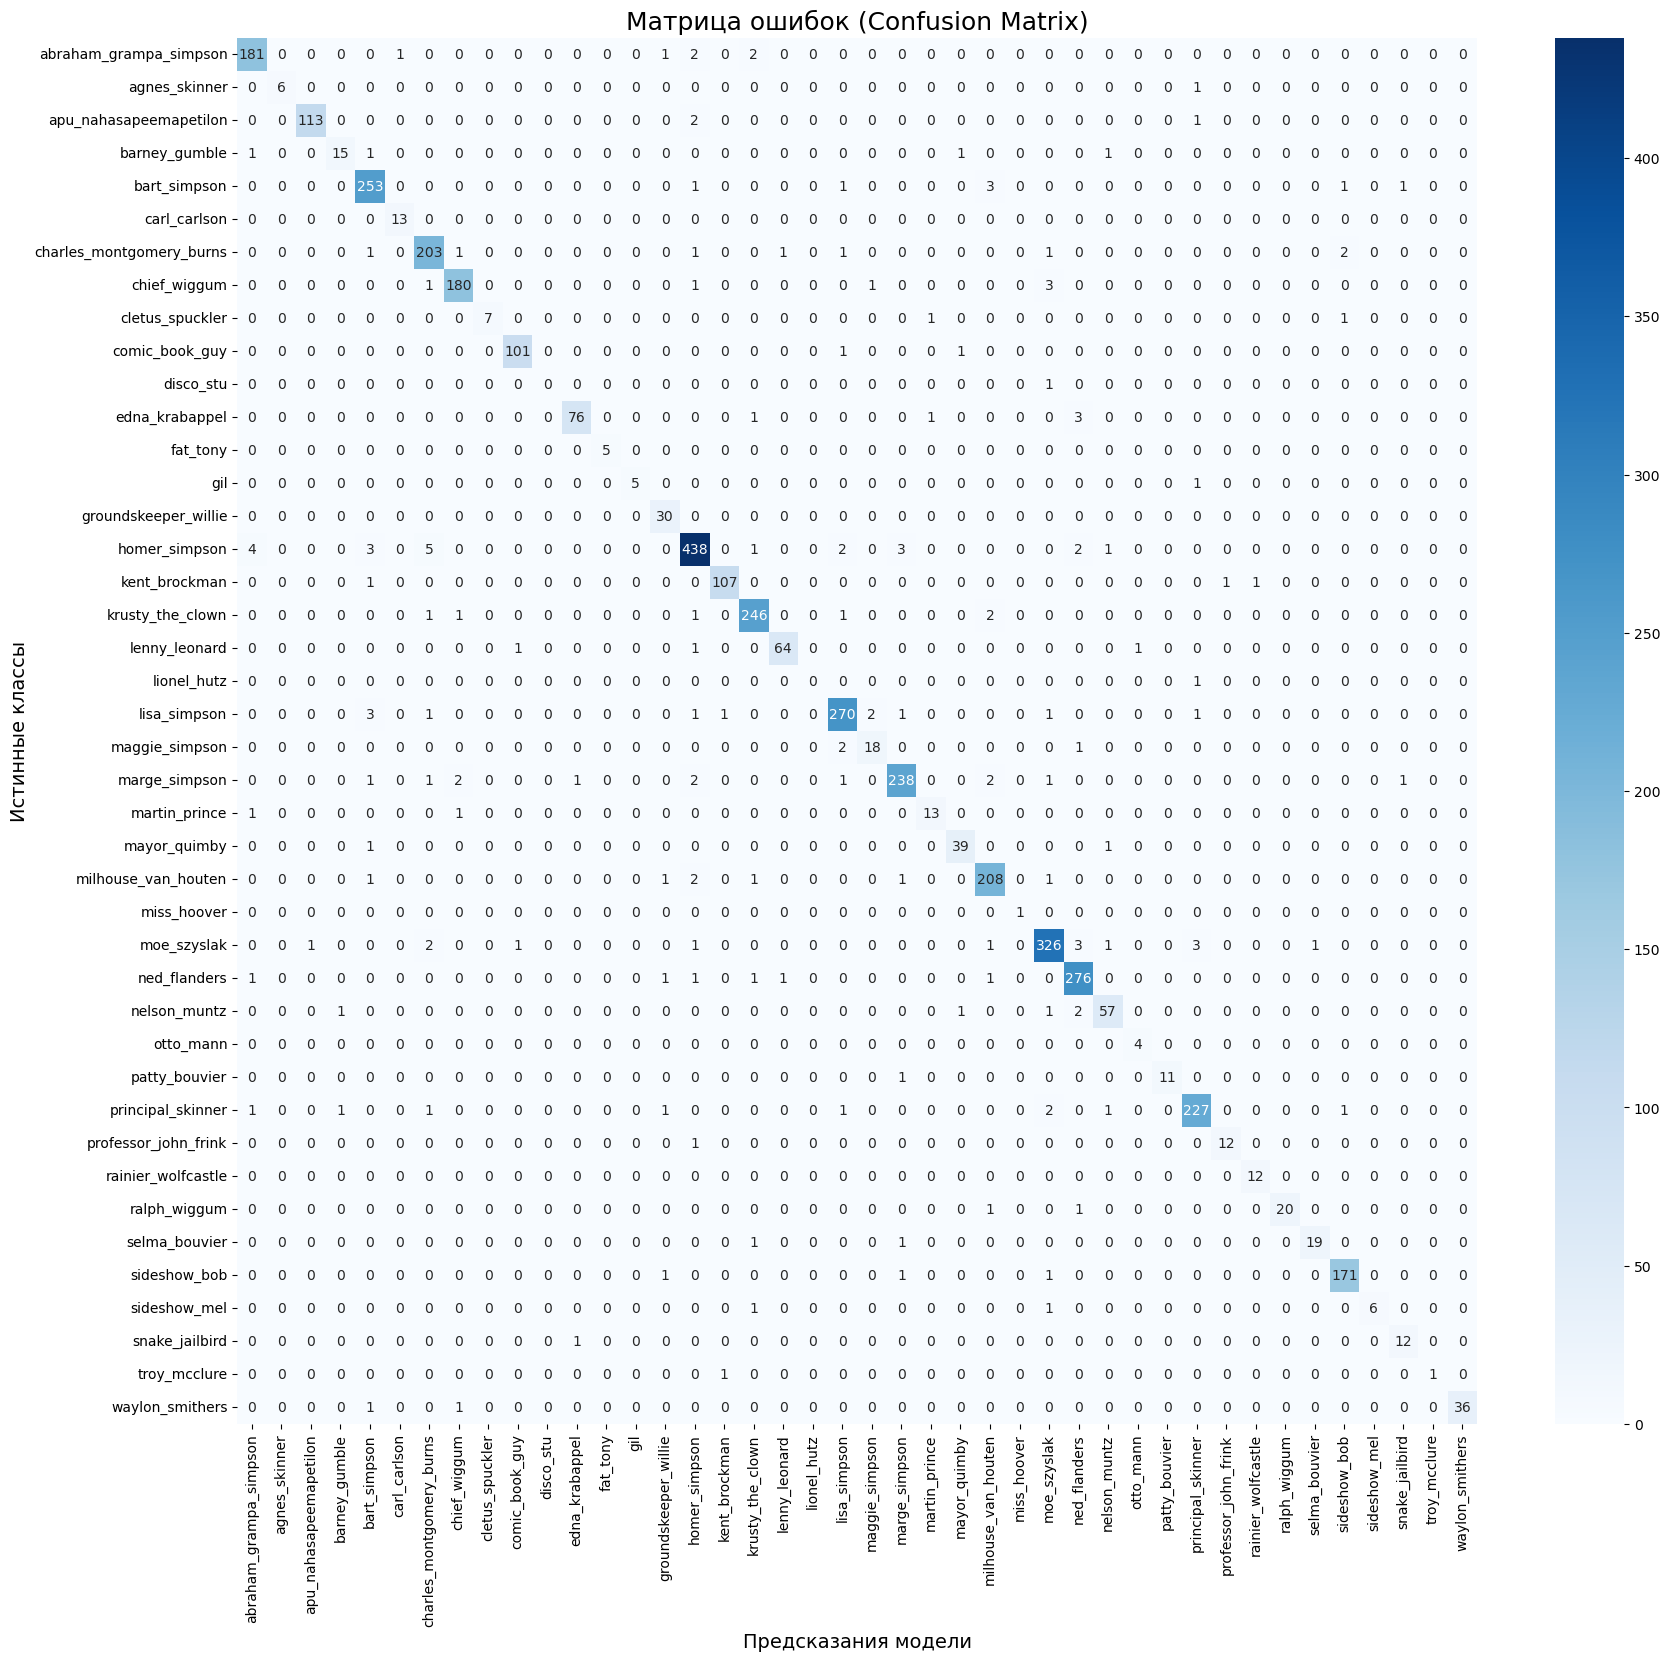

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        # Получаем предсказания модели
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        # Собираем данные т.е переносим с gpu обратно на процессор
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Получаем имена классов по порядку (от 0 до 41)
class_names = test_dataset.dataset.classes

# Считаем матрицу ошибок
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказания модели', fontsize=14)
plt.ylabel('Истинные классы', fontsize=14)
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)